CST1440 Groupwork for M01087449 and M01119165

#HEADER
- The scenarion my teammate and i have chosen to work on is Scenario 3 - Predicting IMDB Rating of new movies for a movie studio
- The program uses a regression model which takes variables Runtime, Genre, Certificate, Director, Star1, Star2, Star3, Star4 as features to predict the rating(label).
- We would need to include a function in the end to input these variables to the program
- The output will be the predicted rating. It will be numeric so it is easy to understand.


In [ ]:
import pandas as pd
movies = pd.read_csv("imdb_top_1000.csv")
movies = movies[["Certificate","Runtime","Genre","IMDB_Rating","Director","Star1","Star2","Star3","Star4"]]
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  \
0             A  142 min                     Drama          9.3   
1             A  175 min              Crime, Drama          9.2   
2            UA  152 min      Action, Crime, Drama          9.0   
3             A  202 min              Crime, Drama          9.0   
4             U   96 min              Crime, Drama          9.0   
..          ...      ...                       ...          ...   
995           A  115 min    Comedy, Drama, Romance          7.6   
996           G  201 min            Drama, Western          7.6   
997      Passed  118 min       Drama, Romance, War          7.6   
998         NaN   97 min                Drama, War          7.6   
999         NaN   86 min  Crime, Mystery, Thriller          7.6   

                 Director              Star1              Star2  \
0          Frank Darabont        Tim Robbins     Morgan Freeman   
1    Francis Ford Coppola      Marlon Brando          Al Paci

In [3]:
group = movies.groupby("Certificate")
output = group["Certificate"].count()
print(output)

Certificate
16            1
A           197
Approved     11
G            12
GP            2
PG           37
PG-13        43
Passed       34
R           146
TV-14         1
TV-MA         1
TV-PG         3
U           234
U/A           1
UA          175
Unrated       1
Name: Certificate, dtype: int64


In [4]:
movies = movies.fillna({"Certificate": "Unrated"})
group = movies.groupby("Certificate")
output = group["Certificate"].count()
print(output)
print(output[output >= 10])

Certificate
16            1
A           197
Approved     11
G            12
GP            2
PG           37
PG-13        43
Passed       34
R           146
TV-14         1
TV-MA         1
TV-PG         3
U           234
U/A           1
UA          175
Unrated     102
Name: Certificate, dtype: int64
Certificate
A           197
Approved     11
G            12
PG           37
PG-13        43
Passed       34
R           146
U           234
UA          175
Unrated     102
Name: Certificate, dtype: int64


In [5]:
keep_rows = output[output >= 10].index
movies = movies[movies["Certificate"].isin(keep_rows)]
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  \
0             A  142 min                     Drama          9.3   
1             A  175 min              Crime, Drama          9.2   
2            UA  152 min      Action, Crime, Drama          9.0   
3             A  202 min              Crime, Drama          9.0   
4             U   96 min              Crime, Drama          9.0   
..          ...      ...                       ...          ...   
995           A  115 min    Comedy, Drama, Romance          7.6   
996           G  201 min            Drama, Western          7.6   
997      Passed  118 min       Drama, Romance, War          7.6   
998     Unrated   97 min                Drama, War          7.6   
999     Unrated   86 min  Crime, Mystery, Thriller          7.6   

                 Director              Star1              Star2  \
0          Frank Darabont        Tim Robbins     Morgan Freeman   
1    Francis Ford Coppola      Marlon Brando          Al Paci

In [42]:
group = movies.groupby("Director")
output = group["Director"].count()
print(output)

Director
Aamir Khan             1
Aaron Sorkin           1
Abdellatif Kechiche    1
Abhishek Chaubey       1
Abhishek Kapoor        1
                      ..
Zack Snyder            2
Zaza Urushadze         1
Zoya Akhtar            2
Çagan Irmak            1
Ömer Faruk Sorak       1
Name: Director, Length: 548, dtype: int64


In [7]:
group_1 = movies.groupby("Star1")
output_1 = group_1["Star1"].count()
print(output_1)

Star1
Aamir Khan              7
Aaron Taylor-Johnson    1
Abhay Deol              1
Abraham Attah           1
Adam Driver             1
                       ..
Zbigniew Zamachowski    1
Zooey Deschanel         1
Çetin Tekindor          1
Éric Toledano           1
Ömer Faruk Sorak        1
Name: Star1, Length: 652, dtype: int64


In [8]:
group_2 = movies.groupby("Star2")
output_2 = group_2["Star2"].count()
print(output_2)

Star2
Adesh Prasad            1
Adil Hussain            1
Adèle Exarchopoulos     1
Adèle Haenel            1
Aidan Gillen            1
                       ..
Zack Gottsagen          1
Zbigniew Zamachowski    1
Zoe Saldana             2
Çetin Tekindor          1
Özge Özberk             1
Name: Star2, Length: 833, dtype: int64


In [9]:
group_3 = movies.groupby("Star3")
output_3 = group_3["Star3"].count()
print(output_3)

Star3
Aamir Khan         1
Aaron Eckhart      1
Abhay Deol         1
Adel Bencherif     1
Adil Hussain       1
                  ..
Zachary Levi       1
Zamira Saunders    1
Zazie Beetz        1
Ziyi Zhang         1
Zoe Saldana        1
Name: Star3, Length: 883, dtype: int64


In [10]:
group_4 = movies.groupby("Star4")
output_4 = group_4["Star4"].count()
print(output_4)

Star4
Aamir Bashir         1
Abdel Ahmed Ghili    1
Abigail Breslin      1
Adam Baldwin         1
Adrien Brody         1
                    ..
Ziyi Zhang           1
Zoe Saldana          1
Zoë Kravitz          1
Álvaro Guerrero      1
Émile Vallée         1
Name: Star4, Length: 931, dtype: int64


In [43]:
movies["Director"] = movies["Director"].map(output)
movies["Star1"] = movies["Star1"].map(output_1)
movies["Star2"] = movies["Star2"].map(output_2)
movies["Star3"] = movies["Star3"].map(output_3)
movies["Star4"] = movies["Star4"].map(output_4)
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  Director  \
0             A  142 min                     Drama          9.3         2   
1             A  175 min              Crime, Drama          9.2         5   
2            UA  152 min      Action, Crime, Drama          9.0         8   
3             A  202 min              Crime, Drama          9.0         5   
4             U   96 min              Crime, Drama          9.0         5   
..          ...      ...                       ...          ...       ...   
995           A  115 min    Comedy, Drama, Romance          7.6         1   
996           G  201 min            Drama, Western          7.6         1   
997      Passed  118 min       Drama, Romance, War          7.6         4   
998         NaN   97 min                Drama, War          7.6        14   
999         NaN   86 min  Crime, Mystery, Thriller          7.6        14   

     Star1  Star2  Star3  Star4  
0      1.0    1.0    1.0    1.0  
1      

In [12]:
movies = movies.copy()
movies[["Runtime_in_nums","Time"]] = movies["Runtime"].str.split(" ", n=1, expand=True)
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  Director  \
0             A  142 min                     Drama          9.3         2   
1             A  175 min              Crime, Drama          9.2         5   
2            UA  152 min      Action, Crime, Drama          9.0         8   
3             A  202 min              Crime, Drama          9.0         5   
4             U   96 min              Crime, Drama          9.0         5   
..          ...      ...                       ...          ...       ...   
995           A  115 min    Comedy, Drama, Romance          7.6         1   
996           G  201 min            Drama, Western          7.6         1   
997      Passed  118 min       Drama, Romance, War          7.6         4   
998     Unrated   97 min                Drama, War          7.6        14   
999     Unrated   86 min  Crime, Mystery, Thriller          7.6        14   

     Star1  Star2  Star3  Star4 Runtime_in_nums Time  
0        1      1   

In [13]:
group = movies.groupby("Genre")
output = group["Genre"].count()
print(output)

Genre
Action, Adventure                5
Action, Adventure, Biography     1
Action, Adventure, Comedy       10
Action, Adventure, Crime         1
Action, Adventure, Drama        14
                                ..
Mystery, Romance, Thriller       1
Mystery, Sci-Fi, Thriller        2
Mystery, Thriller                9
Thriller                         1
Western                          4
Name: Genre, Length: 200, dtype: int64


In [14]:
genre_dummies = movies["Genre"].str.get_dummies(sep = ", ")
movies = pd.concat([movies, genre_dummies],axis=1)
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  Director  \
0             A  142 min                     Drama          9.3         2   
1             A  175 min              Crime, Drama          9.2         5   
2            UA  152 min      Action, Crime, Drama          9.0         8   
3             A  202 min              Crime, Drama          9.0         5   
4             U   96 min              Crime, Drama          9.0         5   
..          ...      ...                       ...          ...       ...   
995           A  115 min    Comedy, Drama, Romance          7.6         1   
996           G  201 min            Drama, Western          7.6         1   
997      Passed  118 min       Drama, Romance, War          7.6         4   
998     Unrated   97 min                Drama, War          7.6        14   
999     Unrated   86 min  Crime, Mystery, Thriller          7.6        14   

     Star1  Star2  Star3  Star4 Runtime_in_nums  ... Horror  Music  Musical

In [15]:
movies_encoded = pd.get_dummies(movies, columns= ["Certificate"])
print(movies_encoded)

     Runtime                     Genre  IMDB_Rating  Director  Star1  Star2  \
0    142 min                     Drama          9.3         2      1      1   
1    175 min              Crime, Drama          9.2         5      2      3   
2    152 min      Action, Crime, Drama          9.0         8      8      2   
3    202 min              Crime, Drama          9.0         5     10      3   
4     96 min              Crime, Drama          9.0         5      3      1   
..       ...                       ...          ...       ...    ...    ...   
995  115 min    Comedy, Drama, Romance          7.6         1      3      1   
996  201 min            Drama, Western          7.6         1      3      1   
997  118 min       Drama, Romance, War          7.6         4      2      1   
998   97 min                Drama, War          7.6        14      1      1   
999   86 min  Crime, Mystery, Thriller          7.6        14      1      1   

     Star3  Star4 Runtime_in_nums Time  ...  Certif

In [16]:
from sklearn.model_selection import train_test_split

x = movies_encoded.drop(columns=["Runtime","Genre","IMDB_Rating","Time"])
y = movies_encoded["IMDB_Rating"]

X_train,X_test,y_train,y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(792, 37)
(199, 37)
(792,)
(199,)


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](37,)","[ 0.01, 0. ,-0. ,..., 0.01,-0.04,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](37,)","['Director','Star1','Star2',...,'Certificate_U','Certificate_UA', 'Certificate_Unrated']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.647
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,37
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,36


In [18]:
print("Intercept: ", model.intercept_) # value of target when the features are 0
print("Coefficients: ", model.coef_) # how much each feature affects the final prediction

Intercept:  7.647335797247017
Coefficients:  [ 0.01301928  0.00462025 -0.000429   -0.01664484  0.03589071  0.00247465
 -0.04806308 -0.06309688  0.04758033 -0.03358521 -0.02517761 -0.00781335
  0.00315525 -0.07858447  0.00724222 -0.04733703 -0.07158371 -0.02671044
 -0.00652543 -0.10668214 -0.02495795 -0.03811194  0.04255484 -0.06291037
 -0.05702352  0.01852429 -0.0786601   0.00586213  0.05079867  0.09534372
 -0.00127091 -0.13880913  0.11959654 -0.09170356  0.00906187 -0.04469371
 -0.00418562]


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Performance
y_pred = model.predict(X_test)

# Accuracy of the model - lower MSE/MAE indictates better performance
print('Mean squared error: ', mean_squared_error(y_test, y_pred))
print('Mean absolute error: ', mean_absolute_error(y_test, y_pred))

# Prediction details - calculates the residuals (prediction errors) and sums their squares to measure the total prediction error
residuals = y_test - y_pred
ssr = sum(residuals ** 2)
print("\nPredicted Values: ", y_pred)
print("\nSum of squared residuals: ", ssr)

# variance of dependent variable (target) explained by independent variables (features)
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("\nR² for each output:", r2)

Mean squared error:  0.05956550204573235
Mean absolute error:  0.19798223154797476

Predicted Values:  [7.95757524 7.98668479 7.67640769 8.15535075 7.91467848 7.86059923
 7.94748539 8.17287824 8.10284708 7.81713714 7.96756451 8.05960259
 8.09107011 7.92594797 7.86198659 8.0305762  8.16314796 7.96097488
 7.89080522 8.14355685 7.99113249 8.06862551 7.89722411 7.92885928
 8.13219741 7.96752157 8.00764833 7.98335797 7.92689594 7.94209985
 7.88887417 8.10013427 8.01709445 8.06106374 7.95322402 8.02090522
 7.92163145 7.97068198 8.13492072 7.9987407  7.85700002 8.03827689
 7.94810948 7.91281038 8.06872249 8.01173174 7.90114282 7.95053663
 7.75302032 7.96906369 8.38269189 8.04945494 7.85422392 8.14872007
 8.16445818 8.06915221 7.87605462 7.96590369 7.9576553  7.953201
 8.00368136 8.00466607 7.85447839 7.93307199 7.99123281 7.99824164
 7.74232145 8.02107365 7.92303453 7.85428784 7.87678263 7.98574558
 8.03168719 8.03924825 7.89540629 7.97377131 7.89962471 7.83600699
 8.10464739 8.03124554 7.988

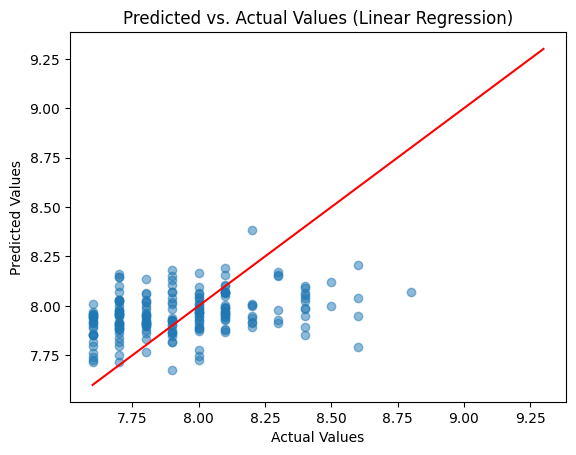

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual Values (Linear Regression)")
plt.show()

Graph interpretation
- The predicted values from the model are clustered within a narrow range in one section of the graph indicating that the model has a low variance and underfits the data.
- The model also underpredicts highly rated movies and overpredicts lower-rated movies. This shows that the current data available lacks sufficient predictive features.

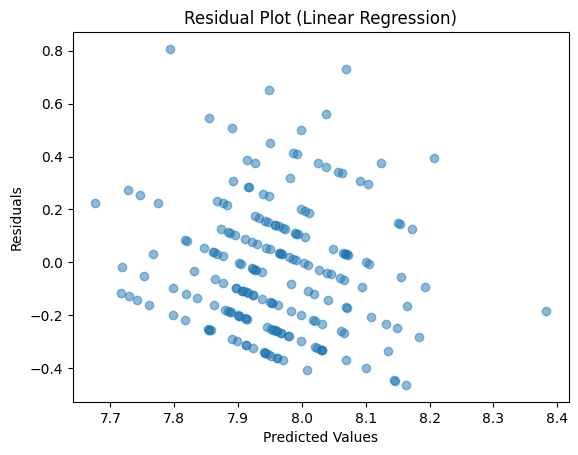

In [21]:
# Plot the residuals
# If the model is a good fit the residual plot should show a random scatter of the points around 0 with no clear trend
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

In [59]:
second_chances = pd.DataFrame(0, index=[0], columns=X_train.columns)
second_chances["Runtime_in_nums"] = 120
second_chances["Drama"] = 1
second_chances["Comedy"] = 1
second_chances["Certificate_PG-13"] = True
second_chances["Director"] = output["Pete Docter"]
second_chances["Star1"] = output_1["Liam Neeson"]
second_chances["Star2"] = output_2["Uma Thurman"]
second_chances["Star3"] = output_3["Kang-ho Song"]

second_chances_pred = model.predict(second_chances)
print("Predicted IMDB Rating for Second Chances: ", second_chances_pred)

Predicted IMDB Rating for Second Chances:  [7.82727686]
